# Geographic Portrait and Flag Map Demo

Phase 2 version: this notebook is now a thin driver around the app-layer workflow.

The app handles geographic data loading, marker-spec construction, flag or portrait asset resolution, rendering, and result tracing.


## Setup


In [1]:
from notebook_bootstrap import (
    display_image,
    image_files,
    init_notebook,
)

ctx, reg = init_notebook()

REPO_ROOT = ctx.repo_root
PROJECT_ROOT = ctx.project_root
SRC_ROOT = ctx.src_root
PACKAGE_SRC = ctx.package_src
CACHE = ctx.cache
RESULTS = ctx.results


/opt/anaconda3/envs/ai_py312/lib/python3.12/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


'NoneType' object has no attribute 'cadam32bit_grad_fp32'
Repo root: /Users/douglasdaly/GitHub/Generative-AI
Project root: /Users/douglasdaly/GitHub/Generative-AI
Package src: /Users/douglasdaly/GitHub/Generative-AI/src/genai_demos/agentic_multimodal
Cache: /Users/douglasdaly/GitHub/Generative-AI/src/genai_demos/agentic_multimodal/cache
Results: /Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal
Legacy artifact roots: ['/Users/douglasdaly/GitHub/Generative-AI/Projects/agentic-multimodal/artifacts']
Legacy cache roots: ['/Users/douglasdaly/GitHub/Generative-AI/Projects/agentic-multimodal/cache']


## Demo parameters


In [2]:
from agentic_multimodal.apps.geo_portrait_map import run_geo_portrait_map

REGION_KEY = "europe_countries_flags"
MAP_REGION = "europe_flags"
MAP_TITLE = "Europe - Flags at Capitals"
MARKER_MODE = "flags"  # "flags" or "people"

MAP_OUTDIR = RESULTS / "maps"
FLAG_CACHE_DIR = ctx.resolve_dir(
    "wikimedia/flags",
    preferred_root=CACHE,
    legacy_roots=ctx.cache_roots,
)

CACHE_POLICY = "reuse"
ALLOW_EXTERNAL_CALLS = False

FLAG_WIDTH = 128
FLAG_TIMEOUT = 10.0
FLAG_RETRIES = 2

MAP_SIZE = (2200, 1320)
MARKER_PX = 42
FLAG_MARKER_SIZE_PX = 42

SHOW_LABELS = True
SHOW_COUNTRY_NAMES = False
SHOW_CAPITAL_NAMES = False
SHOW_PICK_IMAGES = False
SHOW_FLAG_MARKERS = True
SHOW_FALLBACK_DOTS = True
MIN_FLAG_SEPARATION_PX = 0

print("Flag cache directory:", FLAG_CACHE_DIR)


Flag cache directory: /Users/douglasdaly/GitHub/Generative-AI/src/genai_demos/agentic_multimodal/cache/wikimedia/flags


## 1. Flags at capitals

This is the default smoke test. It uses structured country/capital data, caches Wikimedia flag assets, builds a `MapSpec`, and renders a deterministic map.


flag_stats: {'markers': 50, 'has_flag_url': 50, 'thumb_resolved': 0, 'flag_loaded': 50, 'flag_drawn': 50, 'flag_skipped_too_close': 0, 'fallback_dot': 0}
geo_portrait_map: Europe - Flags at Capitals (created) -> /Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal/maps/Europe - Flags at Capitals.png, warnings=1


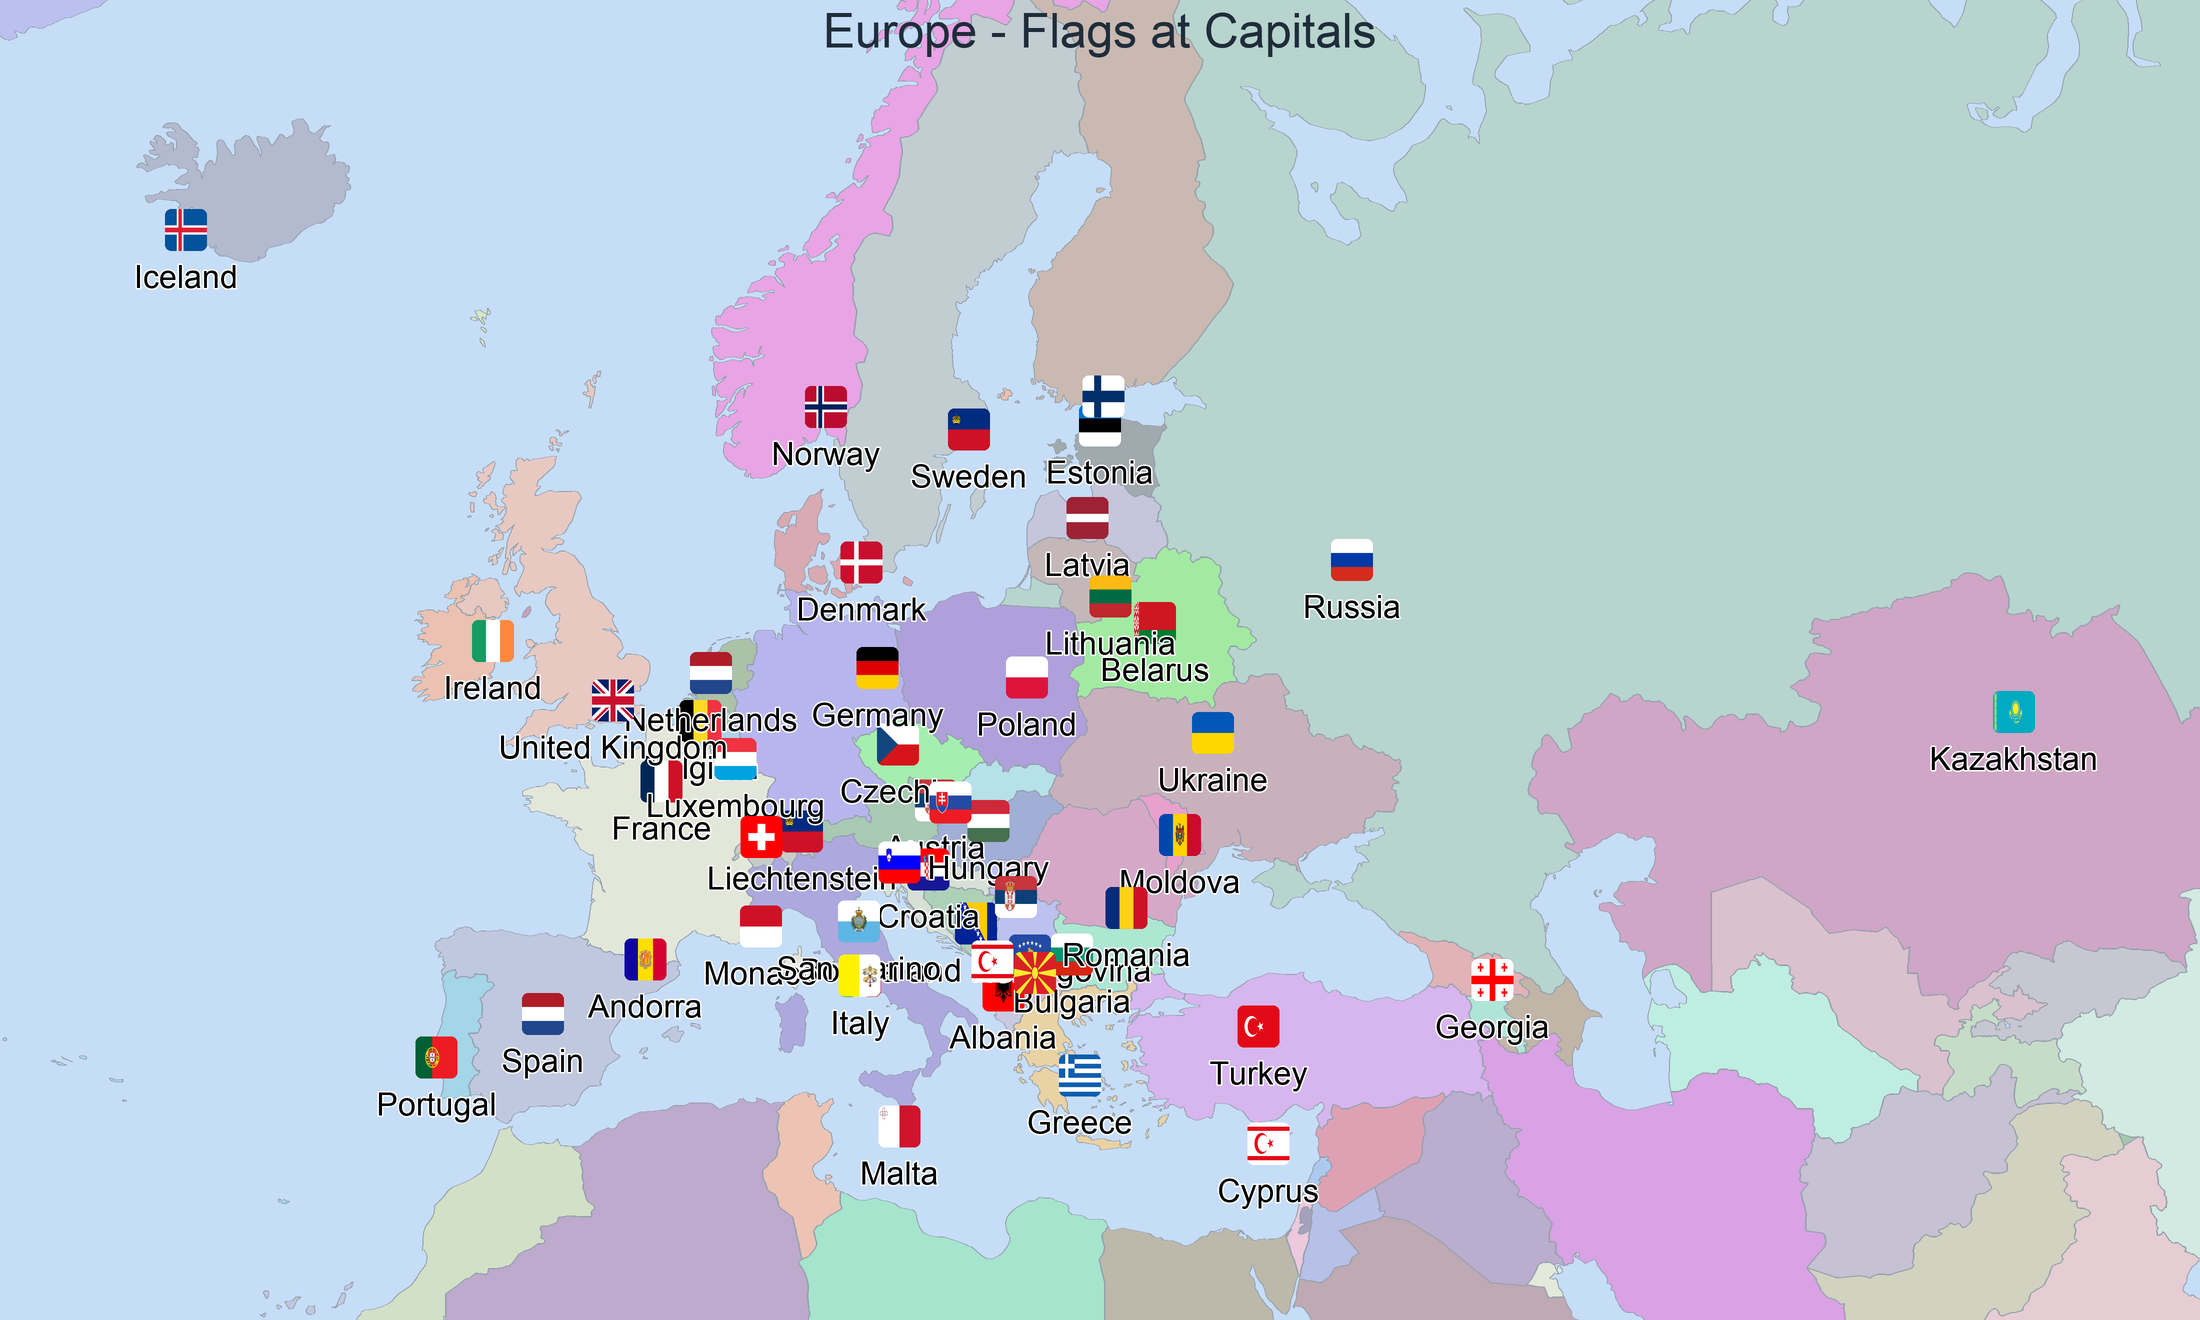

geo_portrait_map: Europe - Flags at Capitals (created) -> /Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal/maps/Europe - Flags at Capitals.png, warnings=1


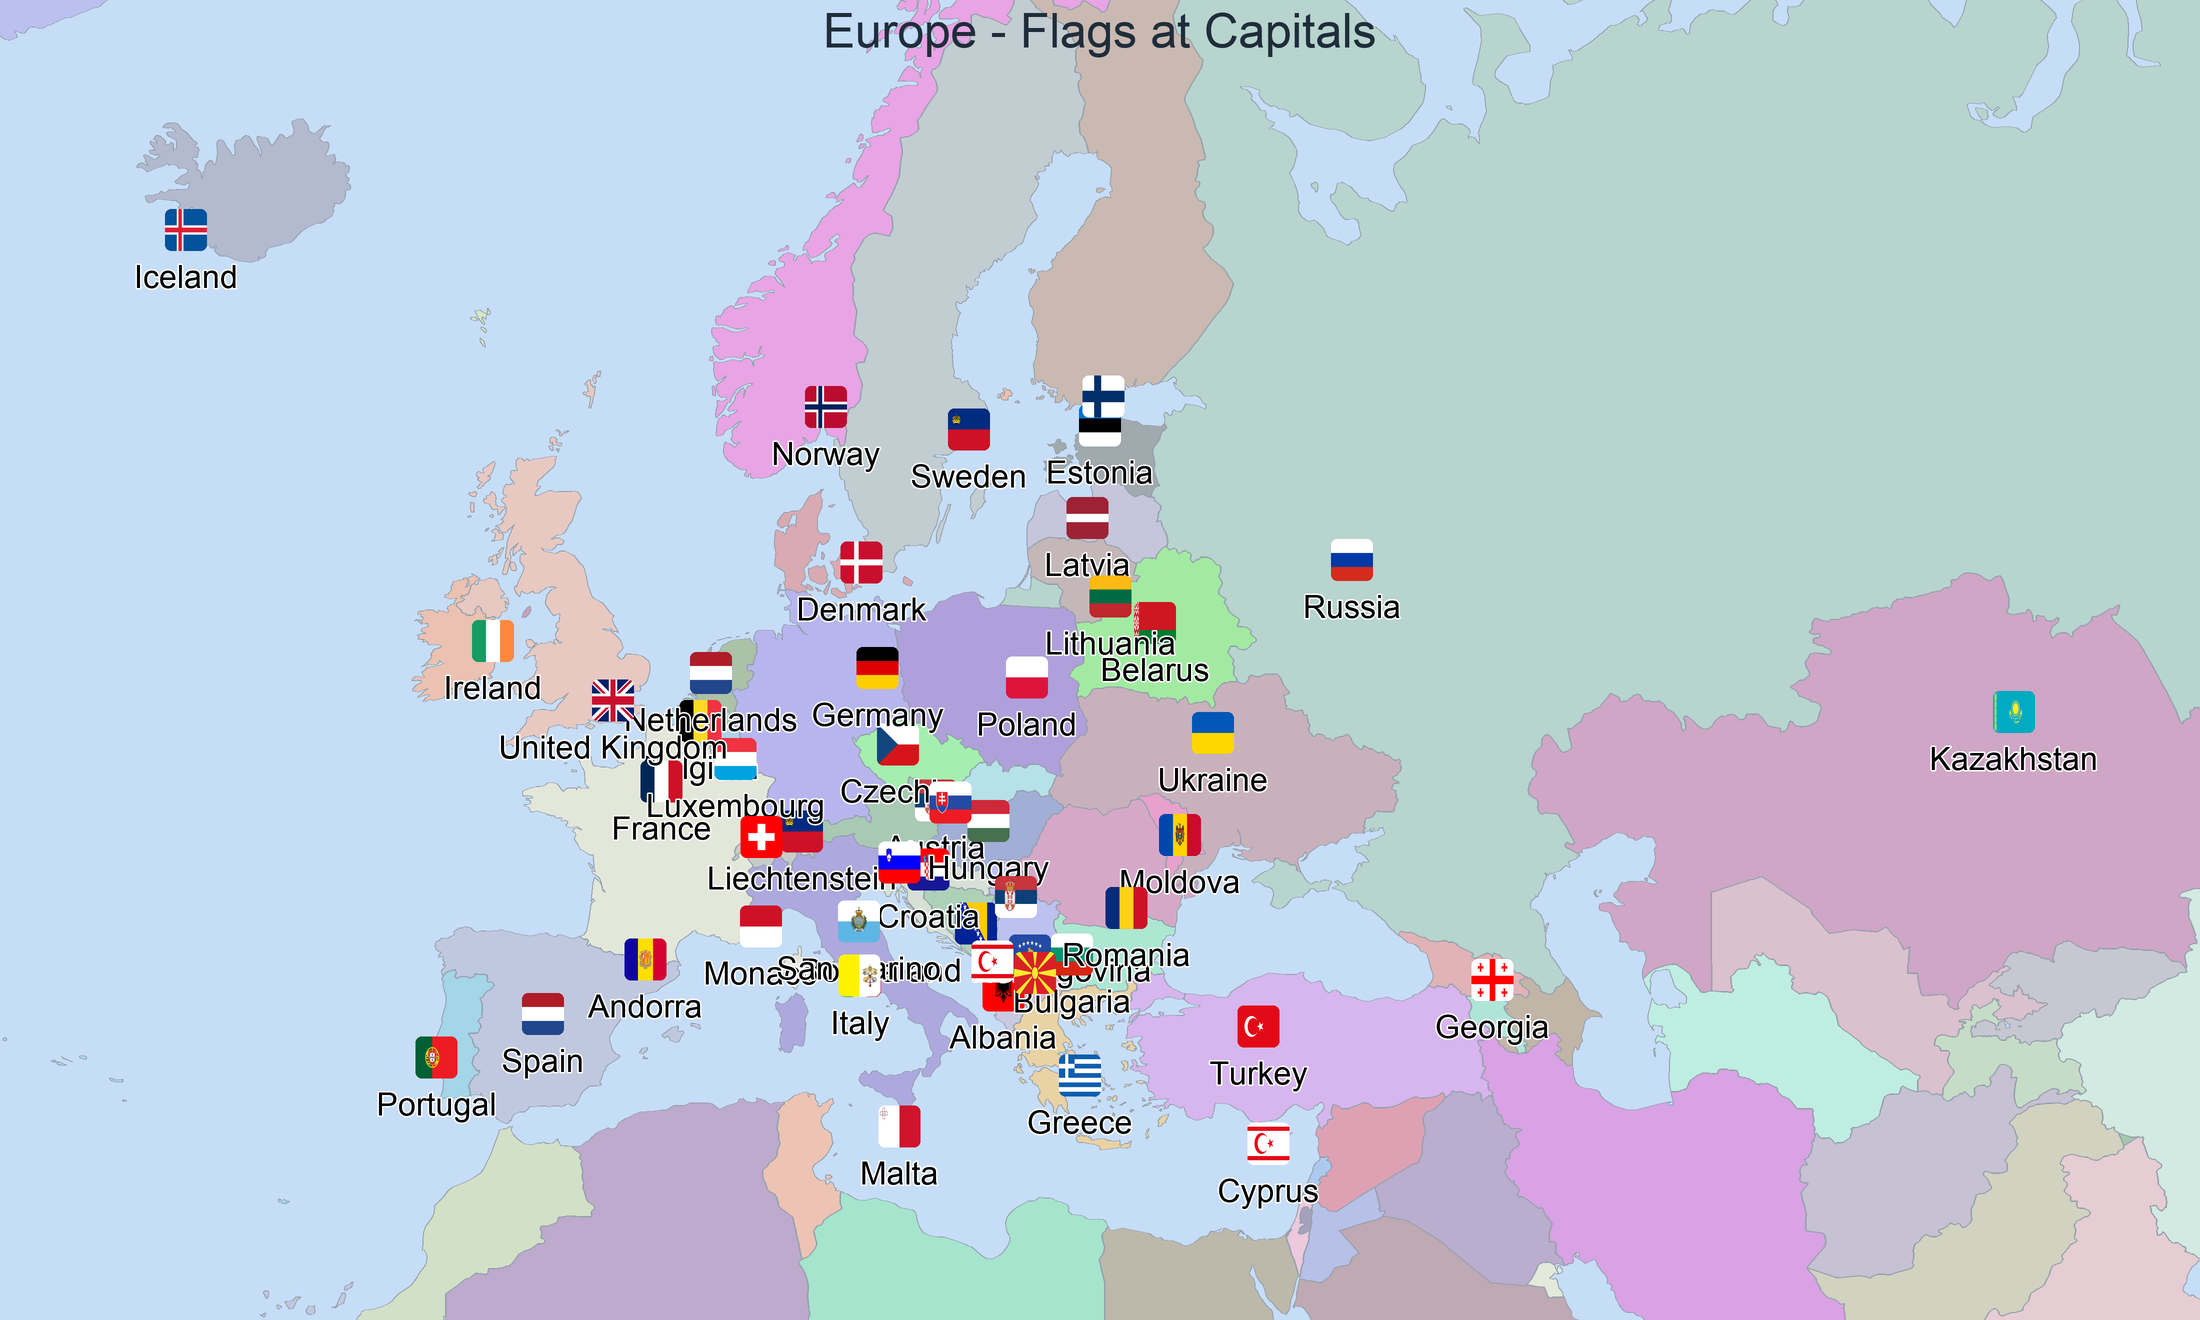

In [ ]:
result = run_geo_portrait_map(
    reg=reg,
    results_dir=RESULTS,
    region_key=REGION_KEY,
    title=MAP_TITLE,
    marker_mode=MARKER_MODE,
    map_region=MAP_REGION,
    map_outdir=MAP_OUTDIR,
    flag_cache_dir=FLAG_CACHE_DIR,
    cache_policy=CACHE_POLICY,
    allow_external_calls=ALLOW_EXTERNAL_CALLS,
    flag_width=FLAG_WIDTH,
    flag_timeout=FLAG_TIMEOUT,
    flag_retries=FLAG_RETRIES,
    size=MAP_SIZE,
    marker_px=MARKER_PX,
    flag_marker_size_px=FLAG_MARKER_SIZE_PX,
    show_labels=SHOW_LABELS,
    show_country_names=SHOW_COUNTRY_NAMES,
    show_capital_names=SHOW_CAPITAL_NAMES,
    show_pick_images=SHOW_PICK_IMAGES,
    show_flag_markers=SHOW_FLAG_MARKERS,
    show_fallback_dots=SHOW_FALLBACK_DOTS,
    min_flag_separation_px=MIN_FLAG_SEPARATION_PX,
)

print(result.summary())
display_image(result.path)


In [4]:
assert result.exists
assert result.kind == "geo_portrait_map"
assert result.trace["region_key"] == REGION_KEY
assert result.trace["marker_mode"] == MARKER_MODE
assert result.cache_summary["flags_fetched"] == 0

print("Geo flag cache reuse smoke checks passed.")

Geo flag cache reuse smoke checks passed.


## Result trace


In [5]:
from pprint import pprint

pprint(result.to_dict())


{'cache_hits': {'flags_reused': 50, 'picks_with_images': 0},
 'cache_misses': {'flags_fetched': 0,
                  'flags_missing': 0,
                  'picks_missing_images': 0},
 'cache_summary': {'allow_external_calls': False,
                   'cache_policy': 'reuse',
                   'countries_loaded': 52,
                   'countries_rendered': 50,
                   'description': 'Reuse cached assets only. Missing assets '
                                  'are reported.',
                   'flags_attached': 50,
                   'flags_available': 50,
                   'flags_fetched': 0,
                   'flags_missing': 0,
                   'flags_resolved': 50,
                   'flags_reused': 50,
                   'marker_mode': 'flags',
                   'picks_missing_images': 0,
                   'picks_selected': 0,
                   'picks_with_images': 0},
 'exists': True,
 'kind': 'geo_portrait_map',
 'path': '/Users/douglasdaly/GitHub/Generative

## Smoke checks


In [6]:
assert result.exists
assert result.kind == "geo_portrait_map"
assert result.trace["region_key"] == REGION_KEY
assert result.trace["marker_mode"] == MARKER_MODE
assert result.trace["marker_count"] > 0

if MARKER_MODE == "flags":
    assert result.cache_summary["flags_resolved"] > 0

print("Geo map app smoke checks passed.")


Geo map app smoke checks passed.


In [7]:
from pathlib import Path

print("Flag cache directory:", FLAG_CACHE_DIR)
files = sorted(Path(FLAG_CACHE_DIR).glob("*"))
print("Flag cache file count:", len(files))
print("First 10 files:")
for path in files[:10]:
    print(" ", path.name)

Flag cache directory: /Users/douglasdaly/GitHub/Generative-AI/src/genai_demos/agentic_multimodal/cache/wikimedia/flags
Flag cache file count: 55
First 10 files:
  flags_manifest_manifest.json
  manifest.json
  q1246_kosovo.png
  q142_france.png
  q145_united_kingdom.png
  q159_russia.png
  q183_germany.png
  q184_belarus.png
  q189_iceland.png
  q191_estonia.png


## 2. Optional: one selected person per country

This is intentionally not the default smoke test. It is slower because it selects people per country and renders portrait markers.

Set `RUN_PEOPLE_MAP = True` to try it.


In [8]:
RUN_PEOPLE_MAP = False

if RUN_PEOPLE_MAP:
    people_result = run_geo_portrait_map(
        reg=reg,
        results_dir=RESULTS,
        region_key=REGION_KEY,
        title="Europe - Notable Sportsperson by Country",
        marker_mode="people",
        map_region="europe_flags",
        map_outdir=MAP_OUTDIR,
        flag_cache_dir=FLAG_CACHE_DIR,
        allow_live_flag_fetch=False,
        portrait_type="sports",
        n_countries=15,
        min_population=2_000_000,
        size=(2200, 1320),
        marker_px=64,
        pick_image_size_px=56,
        show_labels=True,
        show_country_names=False,
        show_capital_names=False,
        show_pick_images=True,
        show_flag_markers=False,
        show_fallback_dots=True,
    )

    print(people_result.summary())
    display_image(people_result.path)
    pprint(people_result.to_dict())
else:
    print("People map skipped. Set RUN_PEOPLE_MAP=True to run it.")


People map skipped. Set RUN_PEOPLE_MAP=True to run it.


## Implementation notes

- The notebook delegates orchestration to `run_geo_portrait_map(...)`.
- The registry owns geo providers, adapters, and renderers.
- The app returns an `ArtifactResult` with the final path, `MapSpec`, trace, cache summary, and warnings.
- Country display names and deduplication should stay in the adapter layer, not in notebook code.
- The people-per-country mode is available but remains secondary to the reliable flag-map smoke test.
